# Local Differential Privacy Training

Dataset: **IPBlock Fraud Detection** (Amazon Fraud Dataset Benchmark)

This notebook corresponds to **Section 5 "Private-data workflow (Local
Differential Privacy)"** of the paper, applied to the fraud detection
task on the IPBlock dataset.

Local DP perturbs each user's record on the client side using the Direct
Encoding mechanism (paper Section 5.2). The IPBlock features (IP octets,
event timestamp components, entity type) are already categorical/discrete,
so no numerical discretization is required (contrast with the Bank Marketing
notebook).

> **Environment**: run this notebook in the `.ldp` virtual environment
> (TensorFlow 2.18, Keras 3, pure-ldp 1.2; see `requirements/ldp.txt`).

> **Data prerequisites**: the three IPBlock CSVs must exist in
> `../data/raw/`. To produce them, run once from the `.fdb` environment:
> `python -m src.fdb_export.export_data`.

In [1]:
import random
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)
from imblearn.combine import SMOTEENN
from boruta import BorutaPy
import xgboost as xgb

import tensorflow as tf
from keras import Sequential
from keras.metrics import AUC
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

from pure_ldp.frequency_oracles.direct_encoding import DEClient

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Paths
ROOT = Path.cwd().resolve()                 # FraudDetection/notebooks
DATA_RAW = ROOT.parent / "data" / "raw"
FIG_DIR = ROOT.parent / "figures"
RES_DIR = ROOT.parent / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Experiment configuration
TARGET = "EVENT_LABEL"
METHOD = "Direct_Encoding"
EPSILONS = [5, 3, 2, 1, 0.5, 0.1]
N_ITERATIONS = 10


In [2]:
# Load IPBlock CSVs and align test labels with test features
train_path = DATA_RAW / "ipblock_train.csv"
test_feat_path = DATA_RAW / "ipblock_test_features.csv"
test_labels_path = DATA_RAW / "ipblock_test_labels.csv"

df_train = pd.read_csv(train_path)
df_test_features = pd.read_csv(test_feat_path)
df_test_labels = pd.read_csv(test_labels_path)

if "EVENT_ID" in df_test_features.columns and "EVENT_ID" in df_test_labels.columns:
    df_test = df_test_features.merge(
        df_test_labels[["EVENT_ID", TARGET]],
        on="EVENT_ID",
        how="left",
    )
else:
    raise ValueError("EVENT_ID is not present in both test tables; cannot align y_test.")

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)


Train shape: (172000, 8)
Test shape : (43000, 7)


## Helper functions

In [3]:
# Engineer the categorical feature set used by Direct Encoding
def engineer_features(df):
    df = df.copy()

    # IP -> first two octets
    df["ip"] = df["ip"].astype(str)
    df["ip_1"] = df["ip"].str.split(".").str[0]
    df["ip_2"] = df["ip"].str.split(".").str[1]

    # Timestamp -> hour, day of week, month, weekend indicator
    dt = pd.to_datetime(df["EVENT_TIMESTAMP"])
    df["event_hour"] = dt.dt.hour
    df["event_dow"] = dt.dt.dayofweek
    df["event_month"] = dt.dt.month
    df["event_is_weekend"] = df["event_dow"].isin([5, 6]).astype(int)

    feature_cols = [
        "ip_1", "ip_2",
        "ENTITY_TYPE",
        "event_hour", "event_dow", "event_month", "event_is_weekend",
    ]

    X = df[feature_cols].copy()
    y = df[TARGET].astype(int).copy()
    return X, y, feature_cols


X_train_raw, y_train, feature_cols = engineer_features(df_train)
X_test_raw,  y_test,  _           = engineer_features(df_test)

print("X_train_raw:", X_train_raw.shape, "y_train:", y_train.shape)
print("X_test_raw :", X_test_raw.shape,  "y_test :", y_test.shape)


X_train_raw: (172000, 7) y_train: (172000,)
X_test_raw : (43000, 7) y_test : (43000,)


In [4]:
y_train.value_counts()


EVENT_LABEL
0    159997
1     12003
Name: count, dtype: int64

In [5]:
y_test.value_counts()


EVENT_LABEL
0    40003
1     2997
Name: count, dtype: int64

In [6]:
# Build the categorical-to-integer mappings and apply them to both folds.
# DEClient expects 1-indexed inputs, so indices start at 1.
def build_cat_mappings(X_train, categorical_cols):
    mappings = {}
    for col in categorical_cols:
        vals = pd.Series(X_train[col].astype(str).unique()).dropna().tolist()
        vals = sorted(set(vals))
        if "nan" in vals:
            vals.remove("nan")
        if "Unknown" not in vals:
            vals.append("Unknown")
        mappings[col] = {v: i + 1 for i, v in enumerate(vals)}
    return mappings


def apply_cat_mappings(X, categorical_cols, mappings):
    X_int = X.copy()
    for col in categorical_cols:
        X_int[col] = X_int[col].astype(str)
        X_int[col] = X_int[col].apply(
            lambda x: x if x in mappings[col] else "Unknown"
        )
        X_int[col] = X_int[col].map(mappings[col]).astype("Int64")
    return X_int


categorical_cols = feature_cols

cat_mappings = build_cat_mappings(X_train_raw, categorical_cols)
X_train_int = apply_cat_mappings(X_train_raw, categorical_cols, cat_mappings)
X_test_int  = apply_cat_mappings(X_test_raw,  categorical_cols, cat_mappings)


In [7]:
# Class-balanced undersampling at 1:1 negative-to-positive ratio
def compute_undersample_indices(y, negative_to_positive_ratio=1.0, random_state=42):
    rng = np.random.RandomState(random_state)
    y_arr = y.values

    idx_pos = np.where(y_arr == 1)[0]
    idx_neg = np.where(y_arr == 0)[0]
    n_pos = len(idx_pos)
    n_neg = len(idx_neg)

    n_neg_desired = min(n_neg, int(n_pos * negative_to_positive_ratio))

    idx_neg_sample = rng.choice(idx_neg, size=n_neg_desired, replace=False)
    idx_keep = np.concatenate([idx_pos, idx_neg_sample])
    idx_keep.sort()

    return idx_keep


train_idx_keep = compute_undersample_indices(
    y_train,
    negative_to_positive_ratio=1.0,
    random_state=SEED,
)

X_train_int_bal = X_train_int.iloc[train_idx_keep].reset_index(drop=True)
y_train_bal = y_train.iloc[train_idx_keep].reset_index(drop=True)

print("Train class distribution (original):")
print(y_train.value_counts())
print("\nTrain class distribution (balanced):")
print(y_train_bal.value_counts())


Train class distribution (original):
EVENT_LABEL
0    159997
1     12003
Name: count, dtype: int64

Train class distribution (balanced):
EVENT_LABEL
1    12003
0    12003
Name: count, dtype: int64


In [8]:
# Apply Direct Encoding perturbation column-by-column with privacy budget epsilon
def apply_de(X_int, categorical_cols, cat_mappings, epsilon, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    X_de = X_int.copy()
    for col in categorical_cols:
        d = len(cat_mappings[col])
        de = DEClient(epsilon=epsilon, d=d)
        X_de[col] = X_de[col].apply(
            lambda x: de.privatise(int(x)) if pd.notna(x) else x
        )
    return X_de


In [9]:
# Save per-feature target-count heatmaps to disk for visual sanity-checking.
# Called once per (method, model) on the first iteration of run_iterations.
def plot_feature_target_count_matrices(
    X_int_or_de, y, categorical_cols, cat_mappings,
    method, model_name, out_dir,
):
    dfp = X_int_or_de.copy()
    dfp["y"] = y.reset_index(drop=True)

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for col in categorical_cols:
        if dfp[col].isna().all():
            continue

        # Reverse mapping (privatized data lands at offset -1 vs originals)
        if method == "Direct_Encoding" and model_name != "Original":
            reverse_mapping = {idx - 1: cat for cat, idx in cat_mappings[col].items()}
        else:
            reverse_mapping = {idx: cat for cat, idx in cat_mappings[col].items()}

        dfp[col] = dfp[col].apply(lambda x: int(x) if pd.notna(x) else x)
        dfp[col] = dfp[col].map(reverse_mapping)
        dfp[col] = dfp[col].fillna("Unknown")

        cm = pd.crosstab(dfp["y"], dfp[col])
        if cm.empty:
            continue

        cats = list(cat_mappings[col].keys())
        if "Unknown" in dfp[col].values and "Unknown" not in cats:
            cats = cats + ["Unknown"]
        cm = cm.reindex(columns=cats, fill_value=0)
        if len(cm) == 1:
            if 0 in cm.index:
                cm.loc[1] = 0
            else:
                cm.loc[0] = 0
            cm = cm.sort_index()
        cm.index = ["y=0", "y=1"]

        plt.figure(figsize=(max(6, len(cats) * 0.4), 3))
        sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", cbar_kws={"label": "Count"})
        plt.title(f"Count Matrix: {col} vs Target ({method}, {model_name})")
        plt.xlabel(col)
        plt.ylabel("Target (y)")
        plt.tight_layout()
        plt.savefig(out_dir / f"count_matrix_{col}.png", dpi=300, bbox_inches="tight")
        plt.close()


In [10]:
# One-hot encode train/test for the neural network and align their columns
def prepare_data_for_nn(X_train_cat_int, y_train, X_test_cat_int, categorical_cols):
    X_train_oh = pd.get_dummies(
        X_train_cat_int, columns=categorical_cols, drop_first=True, dtype="int64",
    )
    X_test_oh = pd.get_dummies(
        X_test_cat_int, columns=categorical_cols, drop_first=True, dtype="int64",
    )

    X_test_oh = X_test_oh.reindex(columns=X_train_oh.columns, fill_value=0)
    y_train = y_train.reset_index(drop=True)
    return X_train_oh, y_train, X_test_oh, X_train_oh.columns


In [11]:
# Feedforward neural network with configurable depth and width
def build_model(input_dim, learning_rate, dropout_rate, units, hidden_layers):
    model = Sequential()
    model.add(Dense(units, activation="relu", input_shape=(input_dim,)))
    model.add(Dropout(dropout_rate))
    for _ in range(hidden_layers - 1):
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[AUC(name="auc")],
    )
    return model


In [12]:
# Grid search over network hyperparameters; validation AUC selects the best
def tune_nn_hyperparams(X_train, y_train, param_grid, epochs=50, batch_size=32, patience=5):
    best_score, best_params = -np.inf, None
    early_stop = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

    for lr, dr, units, hl in product(
        param_grid["learning_rate"],
        param_grid["dropout_rate"],
        param_grid["units"],
        param_grid["hidden_layers"],
    ):
        model = build_model(
            input_dim=X_train.shape[1],
            learning_rate=lr,
            dropout_rate=dr,
            units=units,
            hidden_layers=hl,
        )
        history = model.fit(
            X_train, y_train,
            epochs=epochs, batch_size=batch_size,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0,
        )
        val_auc = max(history.history["val_auc"])
        if val_auc > best_score:
            best_score = val_auc
            best_params = {
                "learning_rate": lr,
                "dropout_rate":  dr,
                "units":         units,
                "hidden_layers": hl,
            }

    return best_params, best_score


In [13]:
# Train one model with the given hyperparameters and report test metrics
def train_and_evaluate_nn(X_train, y_train, X_test, y_test, best_params):
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    model = build_model(
        input_dim=X_train.shape[1],
        learning_rate=best_params["learning_rate"],
        dropout_rate=best_params["dropout_rate"],
        units=best_params["units"],
        hidden_layers=best_params["hidden_layers"],
    )
    model.fit(
        X_train, y_train,
        epochs=50, batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0,
    )

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    an, ap = cm[0].sum(), cm[1].sum()
    fpr = cm[0, 1] / an if an > 0 else 0.0
    fnr = cm[1, 0] / ap if ap > 0 else 0.0

    return {
        "ROC AUC":       roc_auc_score(y_test, y_prob),
        "Accuracy":      accuracy_score(y_test, y_pred),
        "Precision":     precision_score(y_test, y_pred, zero_division=0),
        "Recall":        recall_score(y_test, y_pred, zero_division=0),
        "F1 Score":      f1_score(y_test, y_pred, zero_division=0),
        "Type I Error":  fpr,
        "Type II Error": fnr,
    }


In [14]:
# Repeat the train/evaluate cycle, optionally applying Direct Encoding each time
def run_iterations(
    X_train_int, y_train, X_test_int, y_test,
    categorical_cols, cat_mappings,
    method="none", epsilon=None, n_iterations=N_ITERATIONS,
    best_params=None, make_heatmaps=True,
):
    assert best_params is not None, "best_params must be provided"
    results = []

    for it in range(n_iterations):
        seed = SEED + it

        if method == "none":
            X_train_it_int = X_train_int.copy()
            X_test_it_int  = X_test_int.copy()
            model_name = "Original"
        elif method == "de":
            X_train_it_int = apply_de(
                X_train_int.copy(), categorical_cols, cat_mappings,
                epsilon=epsilon, random_state=seed,
            )
            X_test_it_int = apply_de(
                X_test_int.copy(), categorical_cols, cat_mappings,
                epsilon=epsilon, random_state=seed + 1000,
            )
            model_name = f"eps_{epsilon}"
        else:
            raise ValueError("method must be 'none' or 'de'")

        if it == 0 and make_heatmaps:
            out_dir = FIG_DIR / METHOD / model_name
            plot_feature_target_count_matrices(
                X_train_it_int, y_train, categorical_cols, cat_mappings,
                method=METHOD, model_name=model_name, out_dir=out_dir,
            )

        X_train_sel, y_train_res, X_test_sel, _ = prepare_data_for_nn(
            X_train_it_int, y_train, X_test_it_int, categorical_cols=categorical_cols,
        )

        metrics = train_and_evaluate_nn(
            X_train_sel, y_train_res, X_test_sel, y_test, best_params,
        )
        results.append(metrics)

        print(
            f"Iteration {it + 1}/{n_iterations}  method={method}  epsilon={epsilon}  "
            f"ROC AUC={metrics['ROC AUC']:.4f}"
        )

    return results


In [15]:
# Aggregate per-iteration metrics into mean/std/min/max
def summarize_results(results):
    df = pd.DataFrame(results)
    return {
        "mean": df.mean().to_dict(),
        "std":  df.std().to_dict(),
        "min":  df.min().to_dict(),
        "max":  df.max().to_dict(),
    }


## Run experiments

In [16]:
# Hyperparameter grid (paper §4.2)
nn_param_grid = {
    "learning_rate": [0.01, 0.001, 0.0001],
    "dropout_rate":  [0.1, 0.2, 0.3],
    "units":         [32, 64, 128],
    "hidden_layers": [2, 3],
}

# Tune once on the non-private balanced training set; reuse params for all runs
X_train_sel_tune, y_train_res_tune, _, _ = prepare_data_for_nn(
    X_train_int_bal, y_train_bal, X_test_int, categorical_cols=categorical_cols,
)

best_params_global, best_val_auc = tune_nn_hyperparams(
    X_train_sel_tune, y_train_res_tune, nn_param_grid,
)
print("Best params  :", best_params_global)
print("Best val AUC :", round(best_val_auc, 4))


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `

Best params  : {'learning_rate': 0.001, 'dropout_rate': 0.3, 'units': 32, 'hidden_layers': 2}
Best val AUC : 0.86


In [17]:
# Non-private baseline ("Original")
results_summary = {}

print("Running Original (no privacy)...")
results_original = run_iterations(
    X_train_int_bal, y_train_bal, X_test_int, y_test,
    categorical_cols, cat_mappings,
    method="none", epsilon=None, n_iterations=1,
    best_params=best_params_global,
)
results_summary["Original"] = summarize_results(results_original)


Running Original (no privacy)...


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 1/1  method=none  epsilon=None  ROC AUC=0.8499


In [18]:
# Direct Encoding models, one per privacy budget
all_results = {}
for eps in EPSILONS:
    print(f"\nRunning Direct Encoding (epsilon={eps})...")
    all_results[eps] = run_iterations(
        X_train_int_bal, y_train_bal, X_test_int, y_test,
        categorical_cols, cat_mappings,
        method="de", epsilon=eps, n_iterations=N_ITERATIONS,
        best_params=best_params_global,
    )
    results_summary[f"eps_{eps}"] = summarize_results(all_results[eps])

# Assemble wide-format results table
rows = {}
for model_name, stats in results_summary.items():
    rows[(model_name, "mean")] = stats["mean"]
    rows[(model_name, "std")]  = stats["std"]
    rows[(model_name, "min")]  = stats["min"]
    rows[(model_name, "max")]  = stats["max"]

final_df = pd.DataFrame(rows).round(4)
final_df



Running Direct Encoding (epsilon=5)...


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 1/10  method=de  epsilon=5  ROC AUC=0.5918


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 2/10  method=de  epsilon=5  ROC AUC=0.5928


...

c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 9/10  method=de  epsilon=0.1  ROC AUC=0.4955


c:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\.venv-ldp\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iteration 10/10  method=de  epsilon=0.1  ROC AUC=0.4952


Original                       eps_5                          \
                  mean std     min     max    mean     std     min     max   
ROC AUC         0.8499 NaN  0.8499  0.8499  0.5995  0.0066  0.5918  0.6134   
Accuracy        0.7625 NaN  0.7625  0.7625  0.6378  0.0229  0.6116  0.6783   
Precision       0.1953 NaN  0.1953  0.1953  0.0960  0.0029  0.0930  0.1021   
Recall          0.7711 NaN  0.7711  0.7711  0.4980  0.0298  0.4404  0.5272   
F1 Score        0.3116 NaN  0.3116  0.3116  0.1609  0.0040  0.1566  0.1699   
Type I Error    0.2381 NaN  0.2381  0.2381  0.3518  0.0266  0.3039  0.3821   
Type II Error   0.2289 NaN  0.2289  0.2289  0.5020  0.0298  0.4728  0.5596   

                eps_3          ...   eps_1         eps_0.5                  \
                 mean     std  ...     min     max    mean     std     min   
ROC AUC        0.5044  0.0051  ...  0.4874  0.5109  0.5000  0.0048  0.4923   
Accuracy       0.3749  0.0734  ...  0.2654  0.4810  0.3679  0.1047  0.1560   
Precision      0.0704  0.0013  ...  0.0686  0.0714  0.0694  0.0010  0.0677   
Recall         0.6520  0.0797  ...  0.5265  0.7688  0.6506  0.1224  0.5022   
F1 Score       0.1269  0.0019  ...  0.1215  0.1285  0.1251  0.0029  0.1208   
Type I Error   0.6459  0.0848  ...  0.5224  0.7723  0.6533  0.1216  0.5013   
Type II Error  0.3480  0.0797  ...  0.2312  0.4735  0.3494  0.1224  0.1014   

                      eps_0.1                          
                  max    mean     std     min     max  
ROC AUC        0.5098  0.4995  0.0084  0.4897  0.5186  
Accuracy       0.4989  0.3126  0.0860  0.1768  0.4230  
Precision      0.0713  0.0694  0.0010  0.0673  0.0705  
Recall         0.8986  0.7146  0.1063  0.5656  0.8769  
F1 Score       0.1292  0.1263  0.0030  0.1202  0.1303  
Type I Error   0.8996  0.7175  0.1004  0.5877  0.8757  
Type II Error  0.4978  0.2854  0.1063  0.1231  0.4344  

[7 rows x 28 columns]

In [19]:
out_path = RES_DIR / f"{METHOD}_results_ipblock_trainTest.csv"
final_df.to_csv(out_path)
print("Saved results to:", out_path)


Saved results to: C:\Users\danie\OneDrive\Documentos\1 UNIANDES\PAPER DP\differential-privacy-data-analysis\FraudDetection\results\Direct_Encoding_results_ipblock_trainTest.csv


## Plot results

In [21]:
# Grouped bar plot with min/max whiskers for each metric and each model
def plot_results_with_whiskers(stats_dict, title, save_path=None):
    models = list(stats_dict.keys())
    metrics = list(stats_dict[models[0]]["mean"].keys())
    n_metrics, n_models = len(metrics), len(models)

    colors = sns.color_palette("Blues", n_colors=n_models)[::-1]
    bar_width = 0.15
    x_positions = np.arange(n_metrics) * 1.5

    plt.figure(figsize=(11, 6))
    for i, model in enumerate(models):
        means = np.array([stats_dict[model]["mean"][m] for m in metrics])
        mins  = np.array([stats_dict[model]["min"][m]  for m in metrics])
        maxs  = np.array([stats_dict[model]["max"][m]  for m in metrics])
        yerr  = np.vstack([means - mins, maxs - means])
        bar_x = x_positions + (i - (n_models - 1) / 2) * bar_width

        plt.bar(
            bar_x, means,
            width=bar_width, color=colors[i], label=model,
            yerr=yerr, ecolor="#ff9d00", capsize=3,
            error_kw=dict(linewidth=1.5),
        )

    plt.xticks(x_positions, metrics, rotation=45, fontsize=11)
    plt.yticks(fontsize=11)
    plt.title(title, fontsize=16, weight="bold")
    plt.xlabel("Metrics", fontsize=13)
    plt.ylabel("Value", fontsize=13)
    plt.legend(
        title="Models",
        bbox_to_anchor=(1, 1), loc="upper left",
        fontsize=11, title_fontsize=13,
    )
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


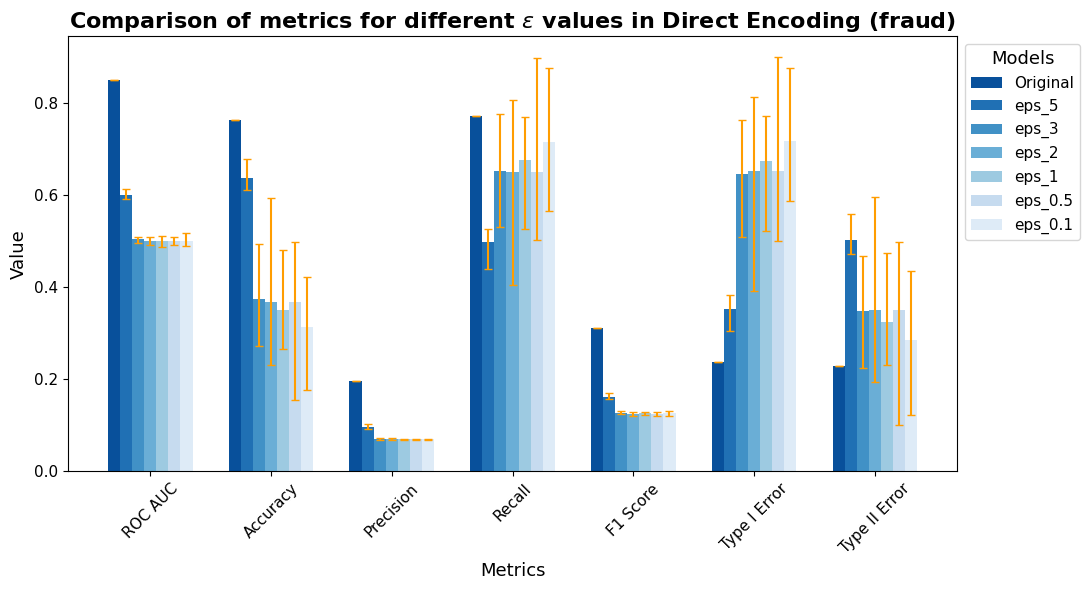

In [22]:
plot_results_with_whiskers(
    results_summary,
    title=r"Comparison of metrics for different $\epsilon$ values in Direct Encoding (fraud)",
    save_path=FIG_DIR / "direct_encoding_results_ipblock.png",
)
